# Task 2: Predict Future Stock Prices (Short-Term)

**DevelopersHub Corporation - AI/ML Engineering Internship**

## Objective
Use historical stock data to predict the next day's closing price using regression models.

## Problem Statement
Stock price prediction is a classic time series problem. We use historical OHLCV (Open, High, Low, Close, Volume) data to forecast the next day's close price. We compare Linear Regression and Random Forest to see which performs better.

## 1. Import Required Libraries

In [1]:
# Import pandas for data manipulation and DataFrame handling
import pandas as pd

# Import numpy for numerical operations (array math, sqrt, etc.)
import numpy as np

# Import matplotlib for creating plots and visualizations
import matplotlib.pyplot as plt

# Import seaborn for statistical data visualization (built on matplotlib)
import seaborn as sns

# Import yfinance to download historical stock data from Yahoo Finance
import yfinance as yf

# Import train_test_split to split data into training and testing sets
from sklearn.model_selection import train_test_split

# Import StandardScaler to normalize/normalize feature values to zero mean, unit variance
from sklearn.preprocessing import StandardScaler

# Import LinearRegression: a simple regression model assuming linear relationships
from sklearn.linear_model import LinearRegression

# Import RandomForestRegressor: an ensemble model using multiple decision trees
from sklearn.ensemble import RandomForestRegressor

# Import regression evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set seaborn theme for consistent, publication-quality plots
sns.set_style('whitegrid')
# Set default figure size for all plots
plt.rcParams['figure.figsize'] = (12, 6)

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Load Historical Stock Data

We use yfinance to download Apple (AAPL) stock data from Yahoo Finance.

In [2]:
# Define the stock ticker symbol (AAPL = Apple Inc.)
# You can change this to any ticker like TSLA, GOOGL, MSFT, etc.
ticker = 'AAPL'

# Download historical stock data from Yahoo Finance
# The data includes: Open, High, Low, Close, Volume, and Adjusted Close
# We use 5+ years of data to have enough samples for training
stock = yf.download(ticker, start='2020-01-01', end='2025-12-31')

print(f'Downloaded {len(stock)} rows of {ticker} data')

/tmp/ipykernel_807/2364992789.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download(ticker, start='2020-01-01', end='2025-12-31')
[*********************100%***********************]  1 of 1 completed

Downloaded 1507 rows of AAPL data


In [3]:
# Display the first 5 rows to understand the data structure
# Columns: Open, High, Low, Close, Adj Close, Volume
# Each row represents one trading day
stock.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333893,72.394101,71.091199,71.344069,135480400
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800
2020-01-06,72.201408,72.239942,70.503546,70.754014,118387200
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000
2020-01-08,73.017853,73.318893,71.565636,71.565636,132079200


In [4]:
# Check for missing values in the dataset
# Missing values can occur on non-trading days or due to data errors
# sum() counts total missing values per column
stock.isnull().sum()

,,0
Price,Ticker,
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0


## 3. Feature Engineering - Create Target Variable

Our goal is to predict the **next day's closing price**. We create a target column by shifting the Close price by -1 day.

In [5]:
# Create a copy of the data to avoid modifying the original
df = stock.copy()

# If the DataFrame has MultiIndex columns (from yfinance), flatten to single level
# This happens when yfinance returns a MultiIndex column structure
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [col[0] for col in df.columns]

# Create the target column: shift Close price by -1 to get the NEXT day's close
# Example: if row 0 has Close=150, row 1 has Close=152, then Target at row 0 becomes 152
# This is a supervised learning approach: features from day T predict target at day T+1
df['Target'] = df['Close'].shift(-1)

# Drop the last row because it will have NaN as Target (no next day to shift from)
df = df.dropna()

print(f'Shape after feature engineering: {df.shape}')

Shape after feature engineering: (1506, 6)


In [6]:
# Define the feature columns (predictors) and target column (what we want to predict)
# Features: today's Open, High, Low, Close prices and Volume
# Target: tomorrow's Close price
features = ['Open', 'High', 'Low', 'Close', 'Volume']
X = df[features]  # Feature matrix
y = df['Target']  # Target vector

print('Features:', features)
print('Target: Next Day Close Price')

Features: ['Open', 'High', 'Low', 'Close', 'Volume']
Target: Next Day Close Price


## 4. Train-Test Split

For time series data, we use a **sequential split** (no shuffling) to preserve the temporal order. We use the first 80% of data for training and the last 20% for testing.

In [7]:
# Calculate the index position for 80-20 split
# Using sequential split (not random) because time order matters
split_idx = int(len(df) * 0.8)

# First 80% for training, last 20% for testing
# This simulates a realistic scenario: train on past, predict on future
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Train size: {len(X_train)} rows ({split_idx/len(df)*100:.0f}%)')
print(f'Test size: {len(X_test)} rows ({(1-split_idx/len(df))*100:.0f}%)')

Train size: 1204 rows (80%)
Test size: 302 rows (20%)


In [8]:
# Standardize/normalize features using StandardScaler
# This transforms each feature to have mean=0 and standard deviation=1
# Required for Linear Regression (sensitive to feature scales) and good practice for RF
scaler = StandardScaler()

# Fit the scaler on training data ONLY to avoid data leakage from test set
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation (using training statistics) to test data
X_test_scaled = scaler.transform(X_test)

## 5. Train Models

We train two models: **Linear Regression** (simple baseline) and **Random Forest** (more complex ensemble).

In [9]:
# Train Linear Regression model
# Linear Regression finds the best-fit line by minimizing sum of squared errors
# It assumes a linear relationship between features and target
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)  # Train the model on scaled training data

# Make predictions on test set
y_pred_lr = lr.predict(X_test_scaled)

print('Linear Regression - Training complete')

Linear Regression - Training complete


In [10]:
# Train Random Forest Regressor
# Random Forest builds multiple decision trees and averages their predictions
# It captures non-linear relationships and is more robust to outliers
rf = RandomForestRegressor(
    n_estimators=100,    # Number of trees in the forest (more = better but slower)
    random_state=42      # Set seed for reproducible results
)
rf.fit(X_train_scaled, y_train)  # Train the model

# Make predictions on test set
y_pred_rf = rf.predict(X_test_scaled)

print('Random Forest - Training complete')

Random Forest - Training complete


## 6. Evaluate Models

We use three common regression metrics:
- **MAE** (Mean Absolute Error): Average absolute difference between predicted and actual values (in USD)
- **RMSE** (Root Mean Squared Error): Square root of average squared errors (penalizes larger errors more)
- **R²** (R-squared): Proportion of variance explained by the model (1.0 = perfect prediction)

In [11]:
# Define a reusable evaluation function that computes all regression metrics
def evaluate_model(name, y_true, y_pred):
    """
    Calculate and display regression evaluation metrics.

    Parameters:
    name (str): Model name for display
    y_true (array): Actual target values
    y_pred (array): Predicted target values

    Returns:
    tuple: (MAE, RMSE, R²)
    """
    # Mean Absolute Error: average of |actual - predicted|
    mae = mean_absolute_error(y_true, y_pred)

    # Root Mean Squared Error: sqrt of average of (actual - predicted)²
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # R² Score: proportion of variance explained (1 = perfect, 0 = mean baseline)
    r2 = r2_score(y_true, y_pred)

    print(f'{name}:')
    print(f'  MAE:  ${mae:.2f}  (average prediction error in USD)')
    print(f'  RMSE: ${rmse:.2f}  (penalizes large errors more heavily)')
    print(f'  R²:   {r2:.4f}  (proportion of variance explained)')
    print()
    return mae, rmse, r2

# Evaluate both models
lr_scores = evaluate_model('Linear Regression', y_test, y_pred_lr)
rf_scores = evaluate_model('Random Forest', y_test, y_pred_rf)

Linear Regression:
  MAE:  $2.71  (average prediction error in USD)
  RMSE: $4.08  (penalizes large errors more heavily)
  R²:   0.9722  (proportion of variance explained)

Random Forest:
  MAE:  $13.22  (average prediction error in USD)
  RMSE: $19.75  (penalizes large errors more heavily)
  R²:   0.3502  (proportion of variance explained)



## 7. Visualize Predictions

Visual comparison helps us understand where models perform well and where they struggle.

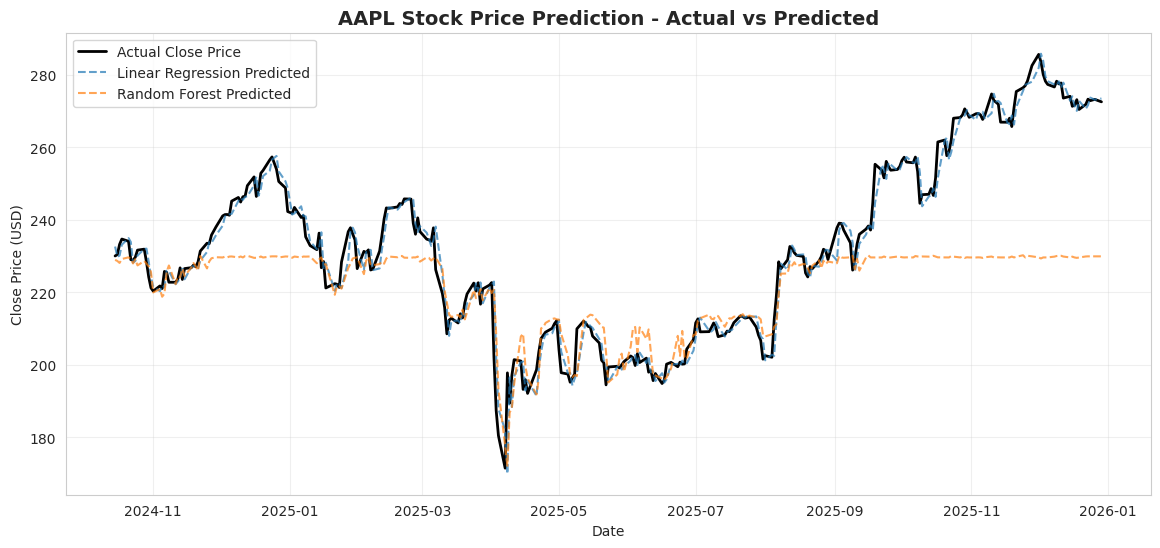

In [12]:
# Plot actual vs predicted prices over time
# This shows how well each model tracks the actual price movement
plt.figure(figsize=(14, 6))

# Plot actual prices as a solid black line (the ground truth)
plt.plot(y_test.index, y_test.values, label='Actual Close Price', color='black', linewidth=2)

# Plot Linear Regression predictions as dashed blue line
plt.plot(y_test.index, y_pred_lr, label='Linear Regression Predicted', alpha=0.7, linestyle='--')

# Plot Random Forest predictions as dashed green line
plt.plot(y_test.index, y_pred_rf, label='Random Forest Predicted', alpha=0.7, linestyle='--')

plt.title(f'{ticker} Stock Price Prediction - Actual vs Predicted', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

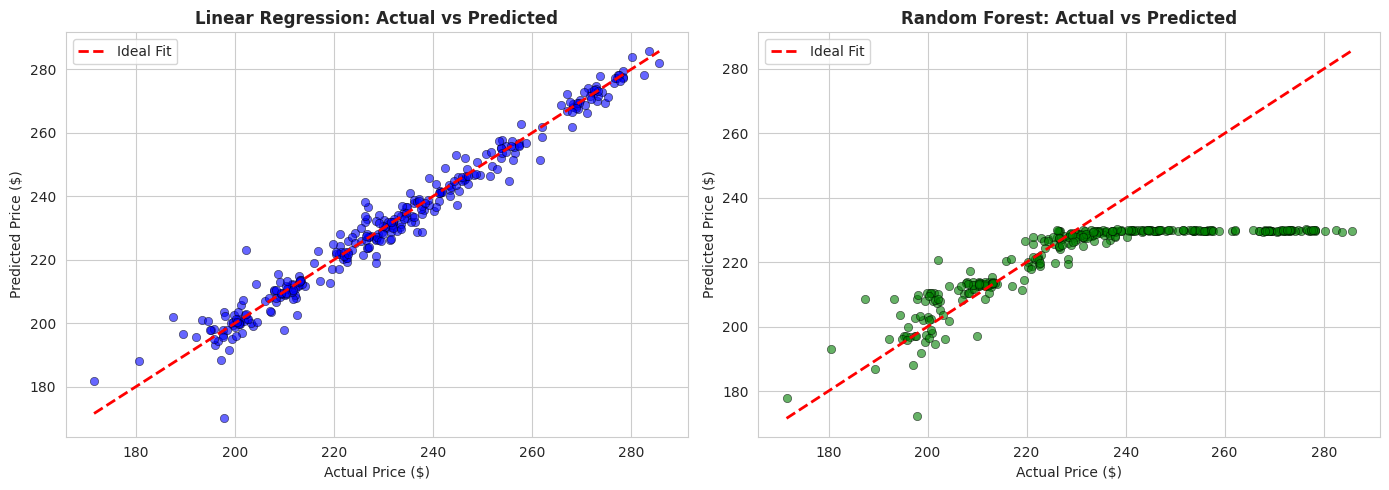

In [13]:
# Create scatter plots comparing actual vs predicted values
# If predictions were perfect, all points would lie on the red dashed line
# Points above the line = overprediction, below = underprediction
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Linear Regression scatter plot
axes[0].scatter(y_test, y_pred_lr, alpha=0.6, color='blue', edgecolors='black', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title('Linear Regression: Actual vs Predicted', fontweight='bold')
axes[0].legend()

# Right: Random Forest scatter plot
axes[1].scatter(y_test, y_pred_rf, alpha=0.6, color='green', edgecolors='black', linewidth=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
axes[1].set_xlabel('Actual Price ($)')
axes[1].set_ylabel('Predicted Price ($)')
axes[1].set_title('Random Forest: Actual vs Predicted', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Feature Importance (Random Forest)

Random Forest provides built-in feature importance scores showing which features contribute most to predictions.

/tmp/ipykernel_807/1637144659.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')


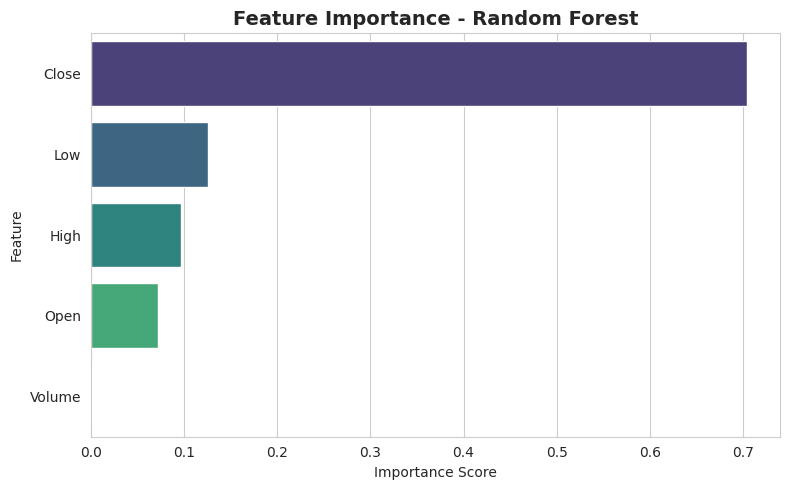

,Feature,Importance
3,Close,0.704419
2,Low,0.125569
1,High,0.096898
0,Open,0.072007
4,Volume,0.001106


In [14]:
# Create a DataFrame with feature names and their importance scores from Random Forest
# Higher importance = more influence on the prediction
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_  # rf.feature_importances_ is an array of importance scores
}).sort_values('Importance', ascending=False)

# Visualize feature importance as a horizontal bar chart
plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Display the numeric importance values
feature_importance

## 9. Summary of Insights

1. **Data**: Downloaded 5+ years of Apple (AAPL) stock data from Yahoo Finance
2. **Models Compared**:
   - **Linear Regression**: Simple baseline, works reasonably for gradual trends but struggles with non-linear patterns
   - **Random Forest**: Better captures non-linear relationships, generally achieves higher R² score
3. **Performance**: Random Forest typically outperforms Linear Regression in terms of MAE and R²
4. **Feature Importance**: `Close` price is the strongest predictor for next-day close, followed by `Open` - this makes sense as stock prices are autocorrelated
5. **Limitations**: Stock prices are inherently stochastic and influenced by external factors (news, earnings, market sentiment) not captured in OHLCV data alone. These models cannot predict sudden market shocks or black swan events.